# import Modules

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Load Dataset

In [6]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
##get catogrical columns
cat_cols=[col for col in df.columns if df[col].dtype=='object']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [8]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
#drop Customer ID
df = df.drop(['customerID'], axis=1)

In [14]:
#Change TotalCharges to numeric datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
#display null values rows
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
#drop rows where tenure is 0
df = df.drop(labels=df[df['tenure']==0].index, axis=0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Exploratory Data analysis

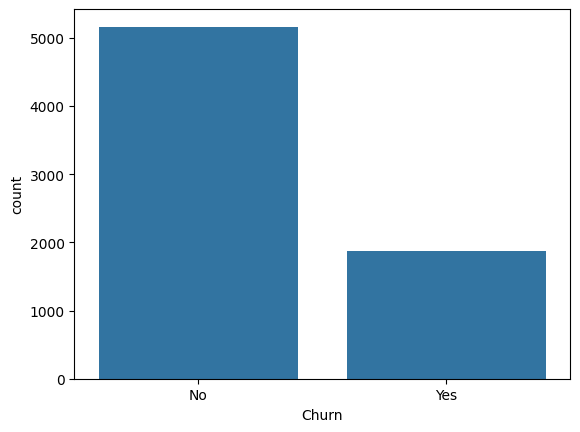

In [21]:
sns.countplot(x='Churn', data=df);

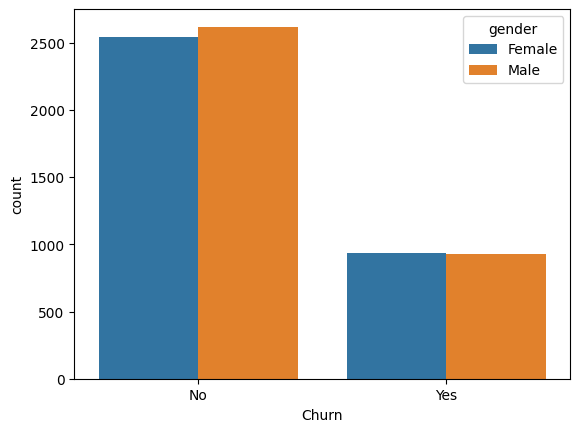

In [23]:
sns.countplot(x='Churn', hue='gender', data=df);

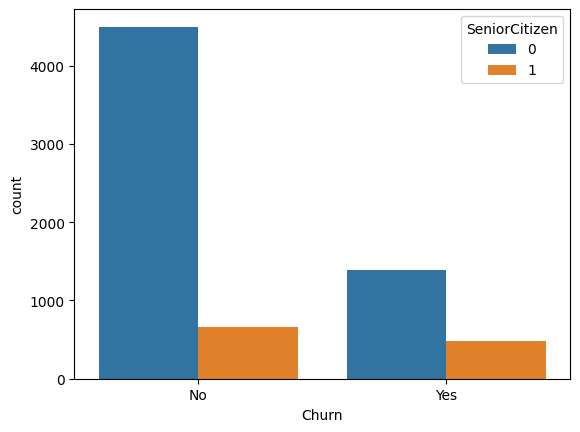

In [24]:
sns.countplot(x='Churn', hue='SeniorCitizen', data=df);

# senior citizen are more likely to churn

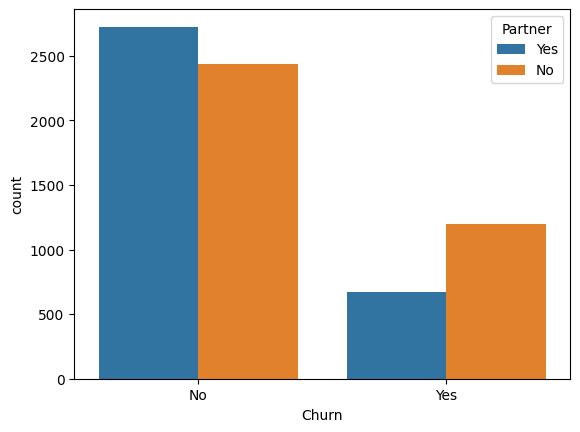

In [25]:
sns.countplot(x='Churn', hue='Partner', data=df);

# people who doesn't have partner or single more like to get to churn

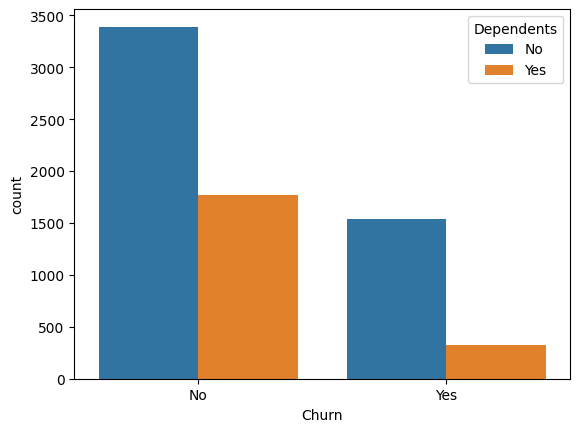

In [26]:
sns.countplot(x='Churn', hue='Dependents', data=df);

# peopele who haven't any dependent or single person more likely to churn
# if a customer has a family, all of then prefer to use same service and retention is high

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


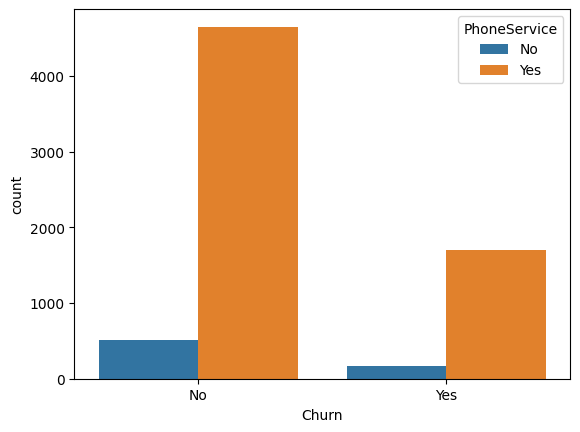

In [27]:
sns.countplot(x='Churn', hue='PhoneService', data=df);

# people who has phone service are more likely to churn

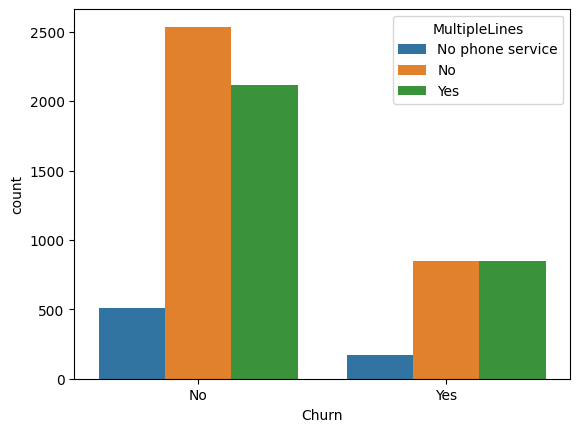

In [32]:
sns.countplot(x='Churn', hue='MultipleLines', data=df);

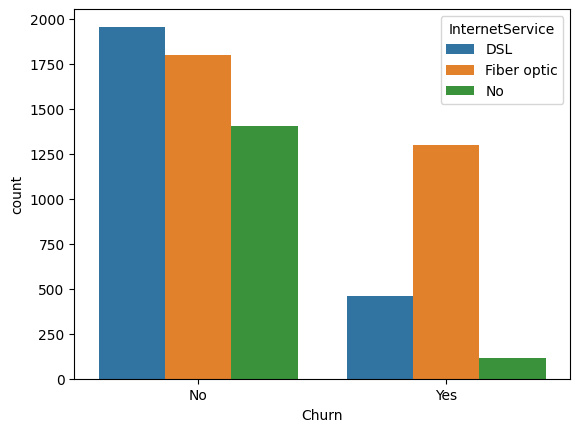

In [33]:
sns.countplot(x='Churn', hue='InternetService', data=df);

# Those who have opted for fiber optic are more likely to churn and on the contrary, those who have DSL services have more retention

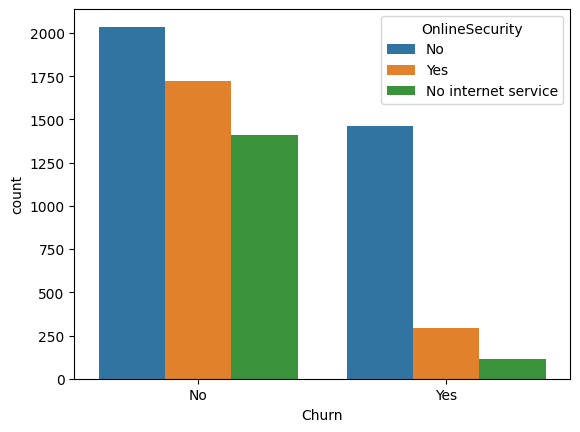

In [34]:
sns.countplot(x='Churn', hue='OnlineSecurity', data=df);

# people who doesn't have online security more likely to churn

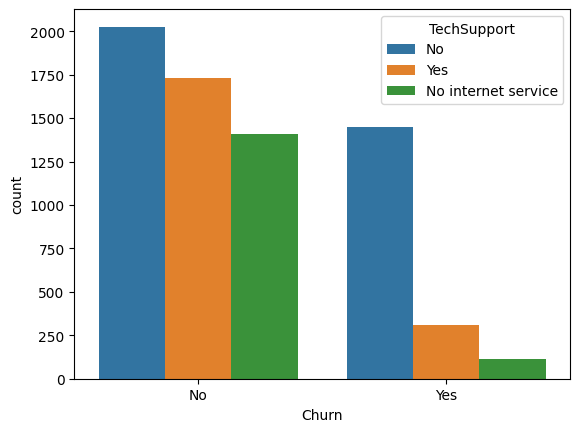

In [35]:
sns.countplot(x='Churn', hue='TechSupport', data=df);

# people who doesn't have tech supoort#  more likely to churn

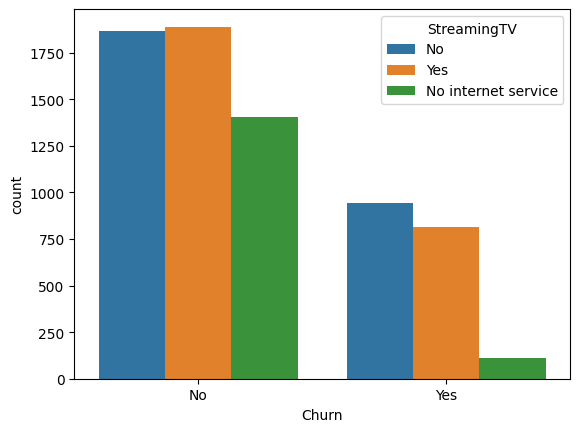

In [37]:
sns.countplot(x='Churn', hue='StreamingTV', data=df);

# people who doesn't have atreming TV more likely to churn

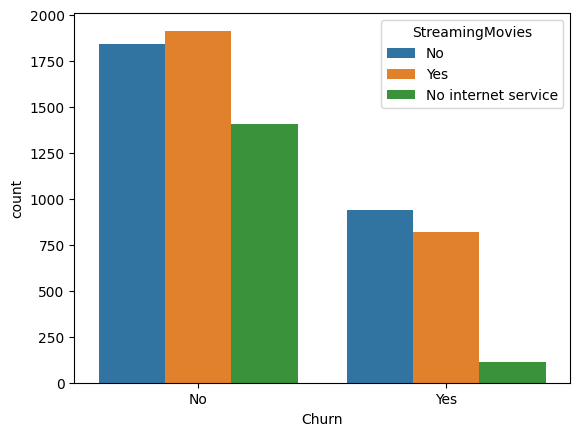

In [39]:
sns.countplot(x='Churn', hue='StreamingMovies', data=df);

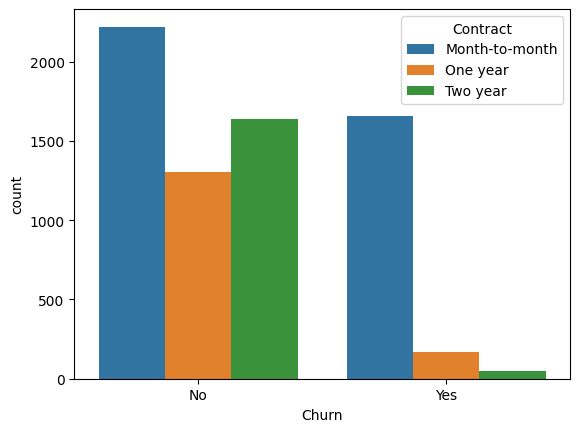

In [41]:
sns.countplot(x='Churn', hue='Contract', data=df);

# people who are on montly contract or more likely to churn and popele who are on yearly contract less likely to churn

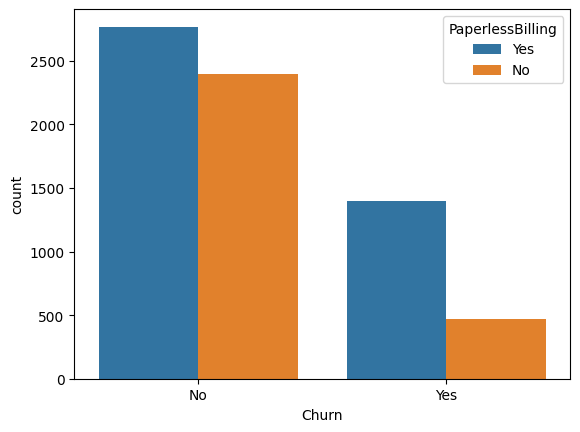

In [42]:
sns.countplot(x='Churn', hue='PaperlessBilling', data=df);

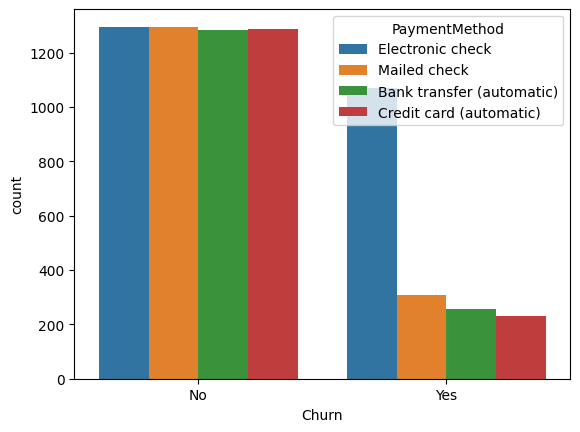

In [43]:
sns.countplot(x='Churn', hue='PaymentMethod', data=df);

# people who have opted for electronic check # payement method are more likely to churn

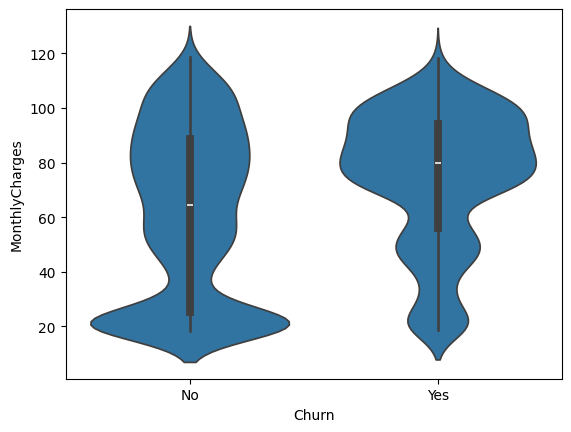

In [47]:
sns.violinplot(x=  "Churn", y = "MonthlyCharges", data=df);

# people who have high monthely charges are more likely to churn# 

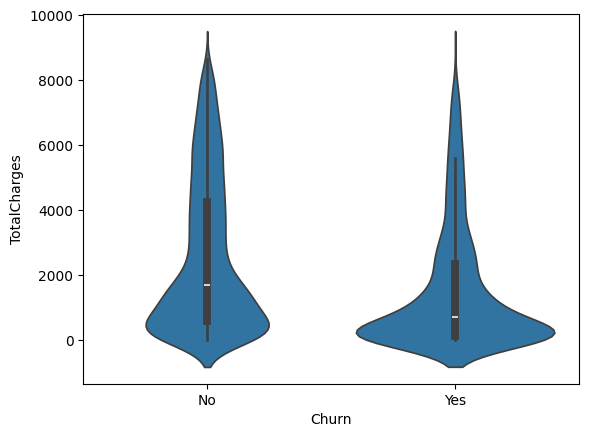

In [49]:
sns.violinplot(x=  "Churn", y = "TotalCharges", data=df);

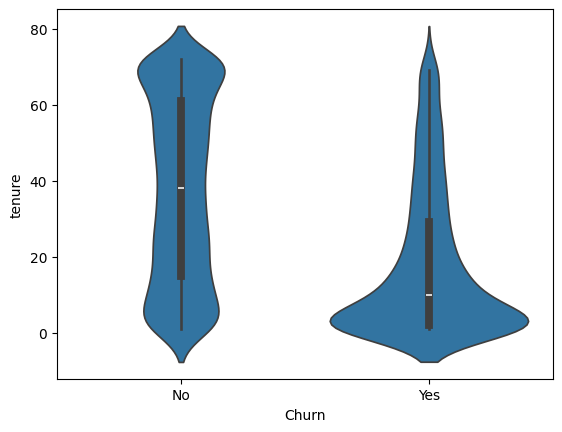

In [50]:
sns.violinplot(x=  "Churn", y = "tenure", data=df);

# people who are on low tenure or who have subscribe for less number of months are more likely to churn

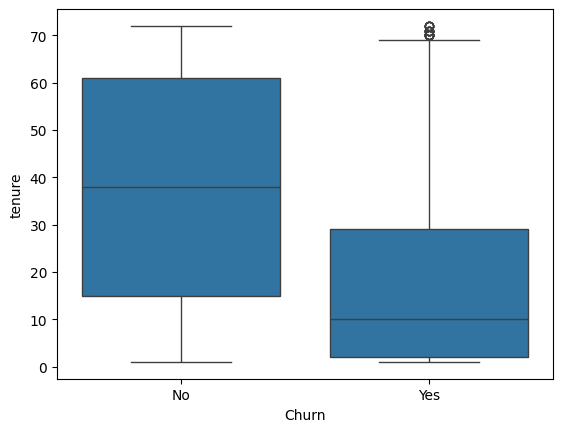

In [51]:
sns.boxplot(x=  "Churn", y = "tenure", data=df);

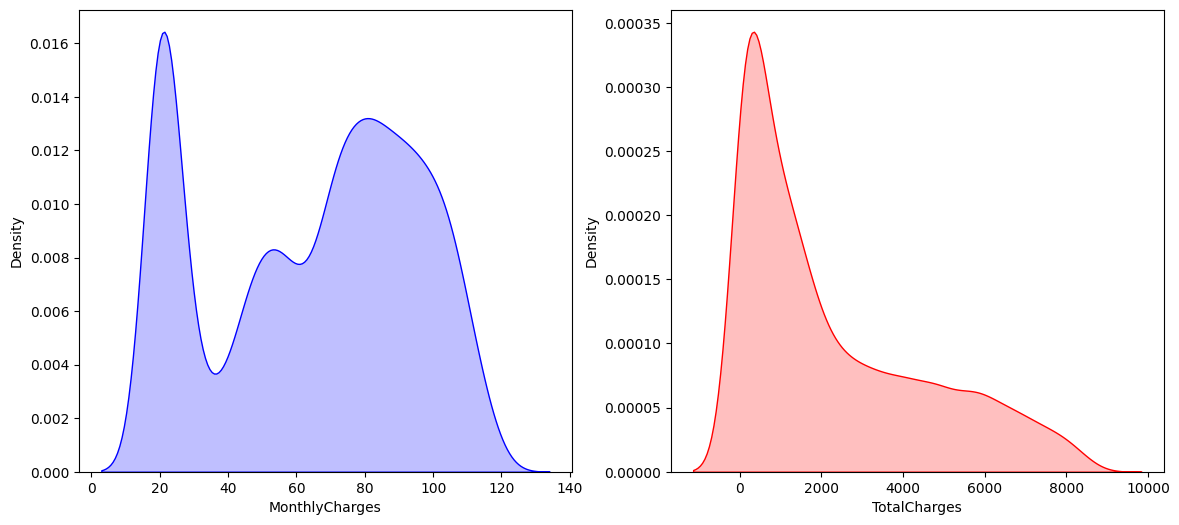

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(df['MonthlyCharges'], ax=axes[0], color='blue', shade=True);
sns.kdeplot(df['TotalCharges'], ax=axes[1], color='red', shade=True);

# Correlation Matrix

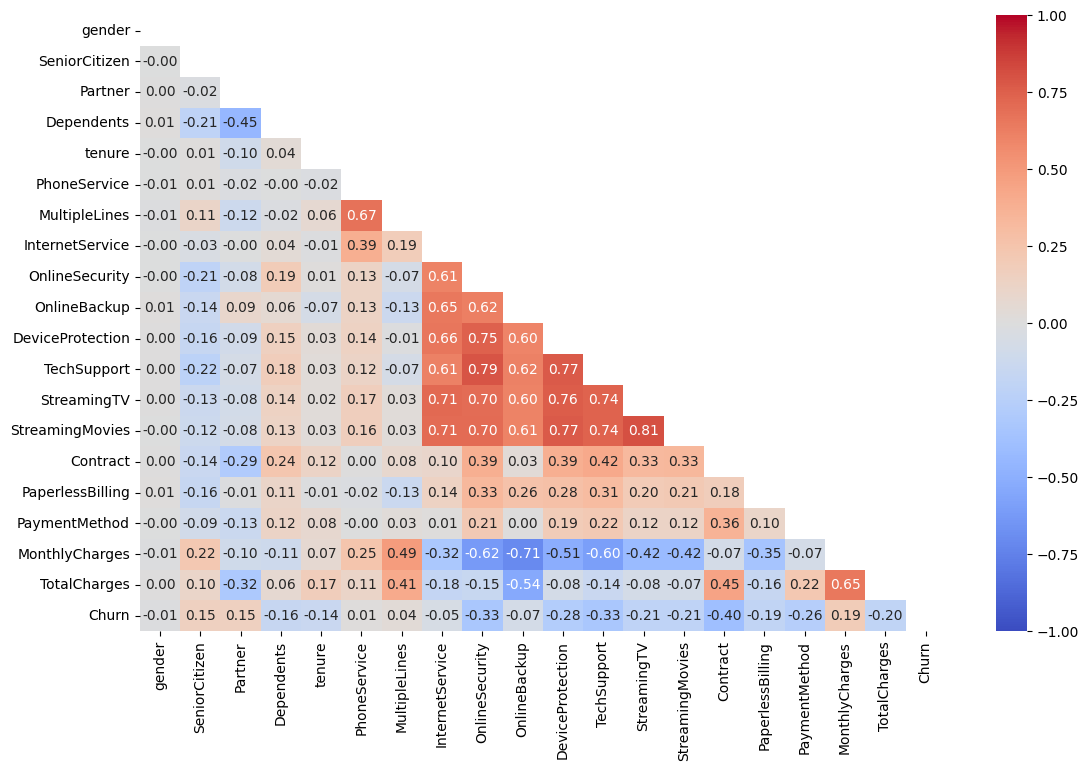

In [61]:
plt.figure(figsize=(13, 8))
corr = df.apply(lambda x:pd.factorize(x)[0] if x.dtype!='float64' else x).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,  annot=True, fmt='.2f');

# Label Encoder 

In [62]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [65]:
cat_cols = [col for col in df.columns if df[col].dtype=='object'] 
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [69]:
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le=LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


In [74]:
#perform log transformation
df['MonthlyCharges']= np.log(df['MonthlyCharges']+1)
df['TotalCharges']= np.log(df['TotalCharges']+1)

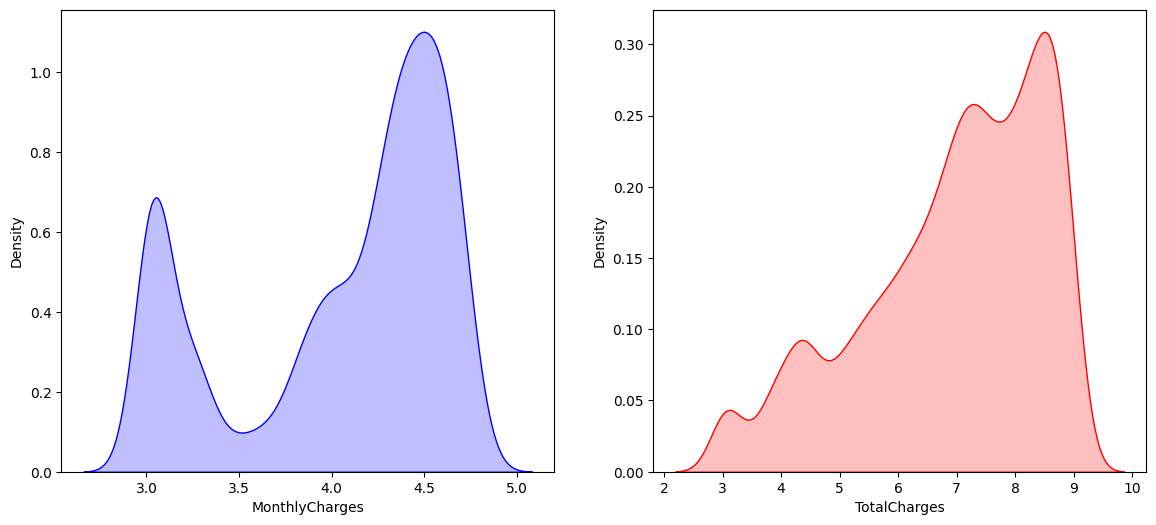

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(df['MonthlyCharges'], ax=axes[0], color='blue', shade=True);
sns.kdeplot(df['TotalCharges'], ax=axes[1], color='red', shade=True);

# Train Test Split

In [78]:
X = df.drop(columns=['Churn'])
y=df['Churn']

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Training

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#intialize and train model
model=LogisticRegression()
model.fit(X_train, y_train)

#get predictions
y_pred=model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [86]:
from sklearn.ensemble import RandomForestClassifier

#intialize and train model
model=RandomForestClassifier()
model.fit(X_train, y_train)

#get predictions
y_pred=model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [94]:
cat_cols.remove('Churn')
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [95]:
from catboost import CatBoostClassifier

#intialize and train model
model=CatBoostClassifier(verbose=False)
model.fit(X_train, y_train, cat_features=cat_cols)

#get predictions
y_pred=model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



# Confusion Matrix

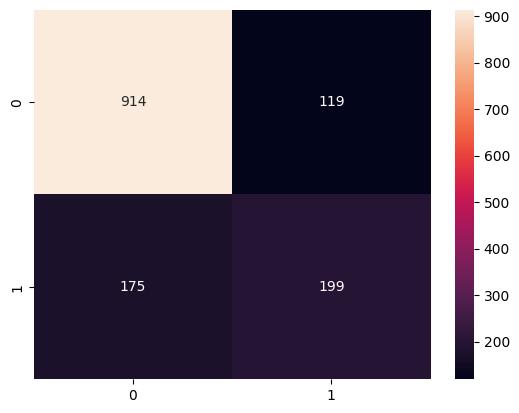

In [100]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d');